# Arbeitsblatt Ableitung

In [6]:
# Bibliotheken

import numpy as np
import matplotlib.pyplot as pl
import matplotlib.ticker as tk
import ipywidgets as iw
%matplotlib widget
from matplotlib.backend_bases import MouseButton

In [7]:
# Koordinatensystem

def KS (size = (5, 4), xticks = (1, 0.5), yticks = (1, 0.5)):

    fig = pl.figure (figsize = size)
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

    ks = fig.add_subplot()
    ks.axis ('equal')
    ks.grid (which = 'both', axis = 'both')
    ks.xaxis.set_major_locator (tk.MultipleLocator (xticks [0]))
    ks.xaxis.set_minor_locator (tk.MultipleLocator (xticks [1]))
    ks.yaxis.set_major_locator (tk.MultipleLocator (yticks [0]))
    ks.yaxis.set_minor_locator (tk.MultipleLocator (yticks [1]))

    return ks

## Experiment: Tangente

Wie gross ist die Steigung der Tangente an die Normalparabel $f \, (x) \;=\; x^2$ an der Stelle $x_0 \;=\; 1$?

In [8]:
def Experiment (f, a, b, n = 1000, size = (8, 5), xticks = (1, 0.5), yticks = (1, 0.5)):

    x = np.linspace (a, b, n)
    y = f (x)

    ks = KS (size, xticks, yticks)
    ks.plot (x, y, color = 'blue', zorder = 2)
    p, = ks.plot ([], [], 'o', color = 'red', zorder = 4)
    s, = ks.plot ([], [], 'red', zorder = 4)

    def Callback (x0, m):

        y0 = f (x0)
        print ('\tx0 = %.5f, y0 = %.5f, \tm = %.5f' % (x0, y0, m))
        p.set_data ([x0], [y0])

        z = y0 + m * (x - x0)
        s.set_data (x, z)

    lay = iw.Layout (width = '700px')
    sldX0 = iw.FloatSlider (layout = lay, min = a, max = b, step = (b - a) / 1000, value = 0.25 * a + 0.75 * b)
    sldM = iw.FloatSlider (layout = lay, min = -10, max = 10, step = 1 / 1000, value = 0.5)
    iw.interact (Callback, x0 = sldX0, m = sldM)

    pl.plot()

interactive(children=(FloatSlider(value=1.0, description='x0', layout=Layout(width='700px'), max=2.0, min=-2.0…

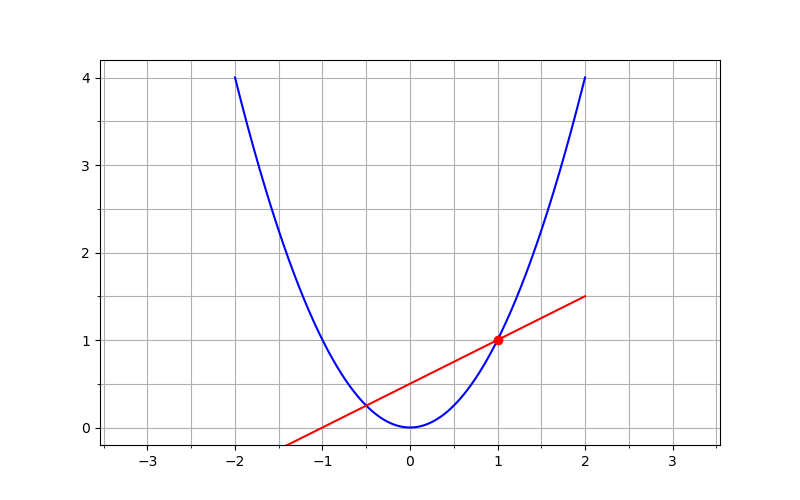

In [9]:
Experiment (lambda x: x ** 2, -2, 2)

## Sekantensteigung

### Sekantensteigung, erste Form

$\displaystyle
    m \;=\; \frac{f \, (x) - f \, (x_0)}{x - x_0}
$

In [10]:
def Sekante1 (f, a, b, n = 1000, size = (8, 5), xticks = (1, 0.5), yticks = (1, 0.5)):

    x = np.linspace (a, b, n)
    y = f (x)

    ks = KS (size, xticks, yticks)
    ks.plot (x, y, color = 'blue', zorder = 2)
    p, = ks.plot ([], [], 'o', color = 'red', zorder = 4)
    q, = ks.plot ([], [], 'o', color = 'blue', fillstyle = 'none', zorder = 3)
    s, = ks.plot ([], [], 'red', zorder = 4)

    def Callback (x0, x1):

        y0 = f (x0)
        y1 = f (x1)
        dx = x1 - x0
        dy = y1 - y0
        p.set_data ([x0], [y0])
        q.set_data ([x1], [y1])

        if x0 != x1:
            m = dy / dx
            z = y0 + m * (x - x0)
            q.set_data ([x1], [y1])
            s.set_data (x, z)
        else:
            m = np.nan
            q.set_data ([], [])
            s.set_data ([], [])

        print ('\tx0 = %.5f, y0 = %.5f, \tx1 = %.5f, y1 = %.5f, \tdx = %.5f, dy = %.5f, \tm = %.5f' % (x0, y0, x1, y1, dx, dy, m))

    lay = iw.Layout (width = '700px')
    sldX0 = iw.FloatSlider (layout = lay, min = a, max = b, step = (b - a) / 1000, value = a + (b - a) * 0.7)
    sldX1 = iw.FloatSlider (layout = lay, min = a, max = b, step = (b - a) / 1000, value = a + (b - a) * 0.8)
    iw.interact (Callback, x0 = sldX0, x1 = sldX1)

    pl.plot()

interactive(children=(FloatSlider(value=0.7999999999999998, description='x0', layout=Layout(width='700px'), ma…

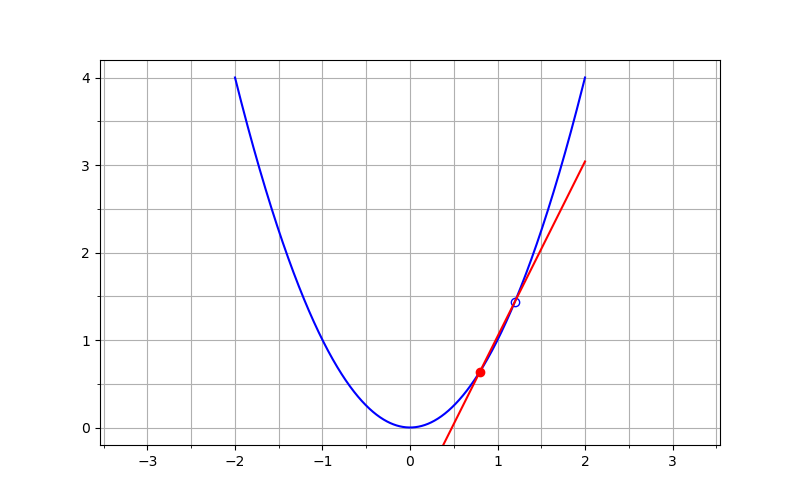

In [11]:
Sekante1 (lambda x: x ** 2, -2, 2)

### Sekantensteigung, zweite Form

$\displaystyle
    m \;=\; \frac{f \, (x_0 + h) - f \, (x_0)}{h}
$

In [12]:
def Sekante2 (f, a, b, n = 1000, size = (8, 5), xticks = (1, 0.5), yticks = (1, 0.5)):

    x = np.linspace (a, b, n)
    y = f (x)

    ks = KS (size, xticks, yticks)
    ks.plot (x, y, color = 'blue', zorder = 2)
    p, = ks.plot ([], [], 'o', color = 'red', zorder = 4)
    q, = ks.plot ([], [], 'o', color = 'blue', fillstyle = 'none', zorder = 3)
    s, = ks.plot ([], [], 'red', zorder = 4)

    def Callback (x0, h):

        x1 = x0 + h
        y0 = f (x0)
        y1 = f (x1)
        p.set_data ([x0], [y0])

        if x0 != x1:
            m = (y1 - y0) / h
            z = y0 + m * (x - x0)
            q.set_data ([x1], [y1])
            s.set_data (x, z)
        else:
            m = np.nan
            q.set_data ([], [])
            s.set_data ([], [])

        print ('\tx = %.5f, y = %.5f, \tm = %.5f' % (x0, y0, m))


    lay = iw.Layout (width = '700px')
    sldX0 = iw.FloatSlider (layout = lay, min = a, max = b, step = (b - a) / 1000, value = 0.25 * a + 0.75 * b)
    sldH = iw.FloatSlider (layout = lay, min = -1, max = 1, step = (b - a) / 1000, value = 0.5)
    iw.interact (Callback, x0 = sldX0, h = sldH)

    pl.plot()

interactive(children=(FloatSlider(value=1.0, description='x0', layout=Layout(width='700px'), max=2.0, min=-2.0…

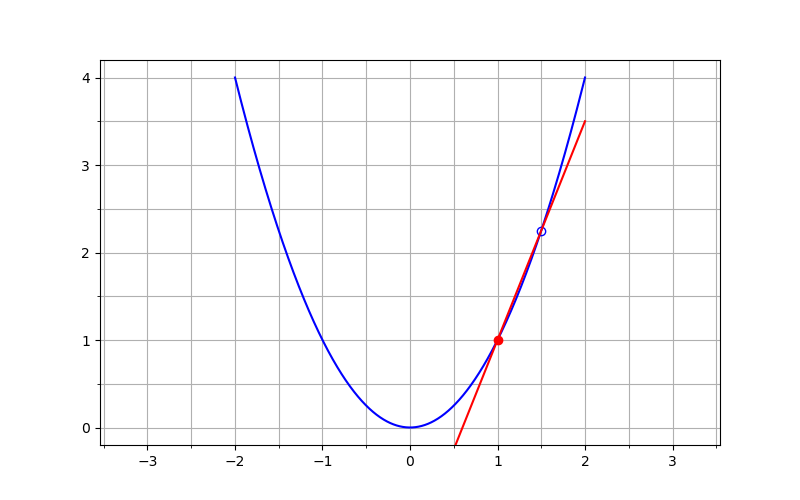

In [13]:
Sekante2 (lambda x: x ** 2, -2, 2)

### Sekantensteigung, weiteres Beispiel

interactive(children=(FloatSlider(value=6.283185307179586, description='x0', layout=Layout(width='700px'), max…

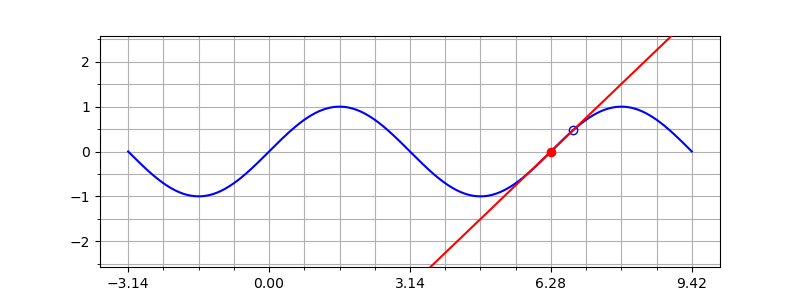

In [14]:
Sekante2 (np.sin, - np.pi, 3 * np.pi, 1000, size = (8, 3), xticks = (np.pi, np.pi / 4))

## Ableitungsfunktion

In [15]:
def Ableitungsfunktion (f, a, b, n = 1000, size = (8, 5), xticks = (1, 0.5), yticks = (1, 0.5)):

    h = 1E-8

    x = np.linspace (a, b, n)
    y = f (x)
    ymax = np.max (np.abs (y))
    ks = KS (size, xticks, yticks)
    ks.plot (x, y, color = 'blue', zorder = 2)
    ks.set_ylim ([-ymax, ymax])
    xx = []
    yy = []
    p, = ks.plot ([], [], 'o', color = 'red', zorder = 4)
    q, = ks.plot (xx, yy, 'o', color = 'magenta', markersize = 2, zorder = 3)
    s, = ks.plot ([], [], 'red', zorder = 4)

    def Callback (x0):

        y0 = f (x0)
        m = (f (x0 + h) - f (x0)) / h
        xx.append (x0)
        yy.append (m)
        p.set_data ([x0], [y0])
        q.set_data ([xx], [yy])

        z = y0 + m * (x - x0)
        #q.set_data ([x1], [y1])
        s.set_data (x, z)

        print ('\tx0 = %.5f, y0 = %.5f, \tm = %.5f' % (x0, y0, m))

    lay = iw.Layout (width = '700px')
    sldX0 = iw.FloatSlider (layout = lay, min = a, max = b, step = (b - a) / 1000, value = a + (b - a) * 0.7)
    iw.interact (Callback, x0 = sldX0)

    pl.plot()

### Ableitungsfunktion von $x^2$

interactive(children=(FloatSlider(value=0.8399999999999999, description='x0', layout=Layout(width='700px'), ma…

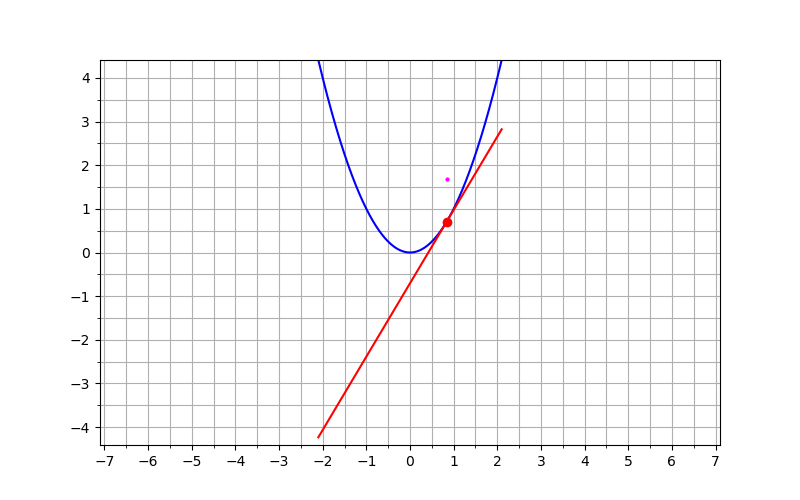

In [16]:
Ableitungsfunktion (lambda x: x ** 2, -2.1, 2.1)

### Ableitungsfunktion von $x^3$

interactive(children=(FloatSlider(value=0.6349604207872797, description='x0', layout=Layout(width='700px'), ma…

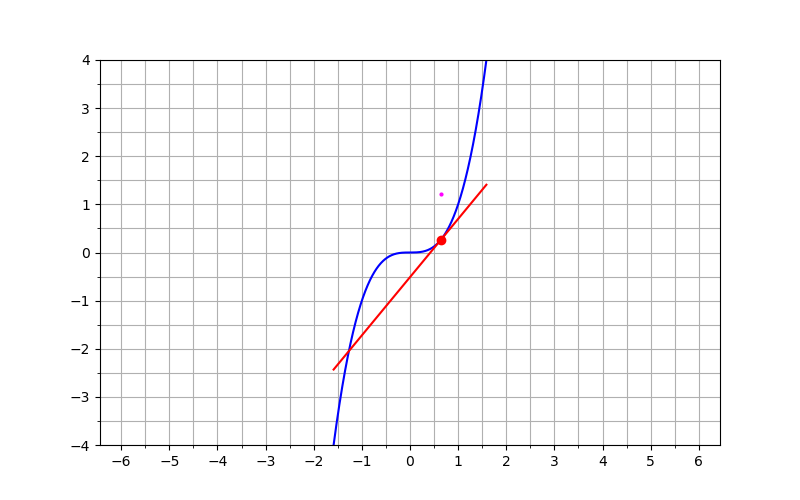

In [17]:
h = 4 ** (1 / 3)
Ableitungsfunktion (lambda x: x ** 3, -h, h)

### Ableitungsfunktion von $x^4$

interactive(children=(FloatSlider(value=0.565685424949238, description='x0', layout=Layout(width='700px'), max…

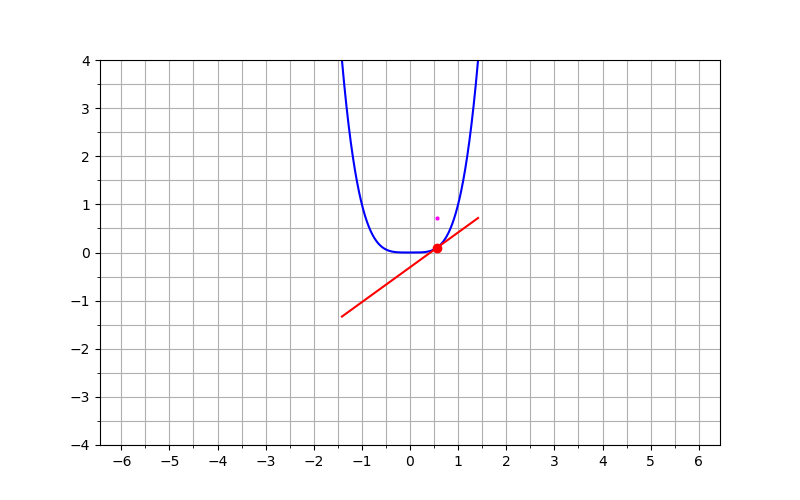

In [18]:
h = 4 ** (1 / 4)
Ableitungsfunktion (lambda x: x ** 4, -h, h)

### Ableitungsfunktion von $\frac{1}{3}\,x^3$

interactive(children=(FloatSlider(value=0.9157713940426655, description='x0', layout=Layout(width='700px'), ma…

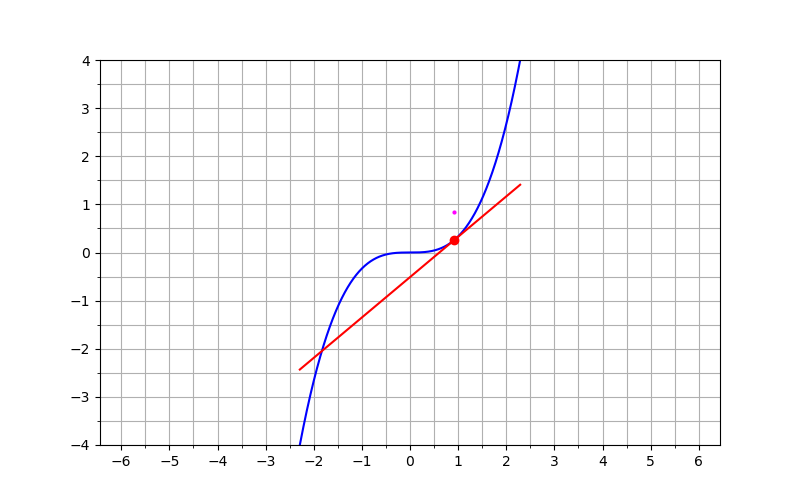

In [19]:
h = 12 ** (1 / 3)
Ableitungsfunktion (lambda x: x ** 3 / 3, -h, h)

### Ableitungsfunktion von $\frac{1}{4}\,x^4$

interactive(children=(FloatSlider(value=0.7999999999999998, description='x0', layout=Layout(width='700px'), ma…

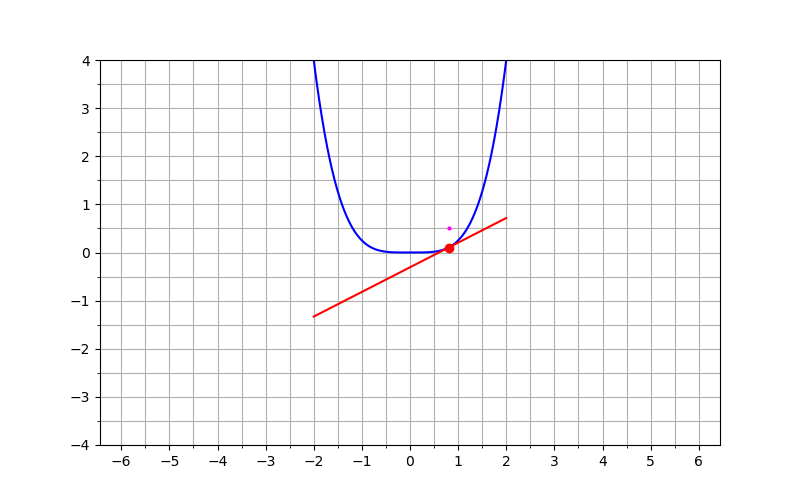

In [20]:
h = 16 ** (1 / 4)
Ableitungsfunktion (lambda x: x ** 4 / 4, -h, h)